In [20]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression



Define Data Paths

In [21]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_DIR


PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw')

In [22]:
# Confirm Data Path
list[Path](DATA_DIR.glob("*.csv"))



[PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Game_Logs_Runningback.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Career_Stats_Receiving.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Career_Stats_Kickoff.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Career_Stats_Rushing.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Career_Stats_Kick_Return.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/Career_Stats_Offensive_Line.csv'),
 PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Pyt

In [23]:
basic_df = pd.read_csv(DATA_DIR / "basic_stats.csv")
basic_df.head()

,Age,Birth Place,Birthday,College,Current Status,Current Team,Experience,Height (inches),High School,High School Location,Name,Number,Player Id,Position,Weight (lbs),Years Played
0,NaN,"Grand Rapids , MI",5/23/1921,Notre Dame,Retired,NaN,3 Seasons,71.0,NaN,NaN,"Evans, Fred",NaN,fredevans/2513736,NaN,185.0,1946 - 1948
1,NaN,"Dayton , OH",12/21/1930,Dayton,Retired,NaN,1 Season,70.0,NaN,NaN,"Raiff, Jim",NaN,jimraiff/2523700,NaN,235.0,1954 - 1954
2,56.0,"Temple , TX",9/11/1960,Louisiana Tech,Retired,NaN,1 Season,74.0,NaN,NaN,"Fowler, Bobby",NaN,bobbyfowler/2514295,NaN,230.0,1985 - 1985
3,30.0,"New Orleans , LA",9/30/1986,LSU,Retired,NaN,5 Seasons,73.0,NaN,NaN,"Johnson, Quinn",NaN,quinnjohnson/79593,NaN,255.0,2009 - 2013
4,25.0,"Detroit , MI",3/31/1992,Central Michigan,Active,Pittsburgh Steelers,3rd season,77.0,Clintondale HS,"Clinton Twp.,Macomb Co., MI","Walton, L.T.",96.0,l.t.walton/2552444,DE,305.0,NaN


In [24]:
qb_game_logs_df = pd.read_csv(DATA_DIR / "Game_Logs_Quarterback.csv")
qb_game_logs_df

,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Ints,Sacks,Sacked Yards Lost,Passer Rating,Rushing Attempts,Rushing Yards,Yards Per Carry,Rushing TDs,Fumbles,Fumbles Lost
0,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,1,08/11,Home,CHI,L,...,--,--,--,0.0,--,--,--,--,--,--
1,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,2,08/18,Away,ARI,W,...,0,0,0,46.9,--,--,--,--,--,--
2,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,3,08/25,Home,DAL,W,...,--,--,--,0.0,--,--,--,--,--,--
3,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,4,08/30,Away,TB,L,...,1,2,13,50.8,2,17,8.5,0,--,--
4,billdemory/2512778,"Demory, Bill",NaN,1974,Regular Season,1,09/15,Away,KC,L,...,--,--,--,0.0,--,--,--,--,--,--
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40242,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,12,12/05,Home,CHI,W,...,2,3,27,25.3,2,0,0.0,0,--,--
40243,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,13,12/12,Away,SD,L,...,3,1,6,37.3,--,--,--,--,--,--
40244,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,14,12/19,Away,OAK,L,...,1,2,13,57.5,1,6,6.0,0,--,--
40245,steveramsey/2523725,"Ramsey, Steve",NaN,1970,Regular Season,13,12/13,Home,SF,L,...,--,--,--,0.0,--,--,--,--,--,--


In [25]:
qb_game_logs_df = qb_game_logs_df[qb_game_logs_df["Year"] >= 1982].copy()
qb_game_logs_df.sort_values(by="Year", inplace=True, ascending=False)
qb_game_logs_df.fillna(0, inplace=True)


In [26]:
qb_game_logs_df_sorted = qb_game_logs_df.sort_values(
    by=["Passer Rating", "Name", "Year"],
    ascending=[False, True, True]
)
qb_game_logs_df_sorted.head(30)

# Remove any row where "Season" is "Preseason"
qb_game_logs_df_sorted = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Season"] != "Preseason"]
qb_high_rating_df = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Passer Rating"].apply(pd.to_numeric, errors='coerce') >= 90]
qb_high_rating_df.head()



,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Ints,Sacks,Sacked Yards Lost,Passer Rating,Rushing Attempts,Rushing Yards,Yards Per Carry,Rushing TDs,Fumbles,Fumbles Lost
28306,derekanderson/2506546,"Anderson, Derek",QB,2014,Regular Season,3,09/21,Home,PIT,L,...,0,0,0,158.3,--,--,--,--,--,--
1359,stevebartkowski/2509103,"Bartkowski, Steve",0,1984,Regular Season,4,09/23,Home,HOU,W,...,0,2,10,158.3,1,0,0.0,0,--,--
1960,charliebatch/2499567,"Batch, Charlie",0,2005,Regular Season,16,12/24,Away,CLE,W,...,0,0,0,158.3,--,--,--,--,--,--
16740,kerwinbell/2499604,"Bell, Kerwin",0,1996,Regular Season,15,12/05,Home,PHI,W,...,0,0,0,158.3,1,-1,-1.0,0,--,--
10784,tombrady/2504211,"Brady, Tom",QB,2007,Regular Season,7,10/21,Away,MIA,W,...,0,1,10,158.3,--,--,--,--,--,--


In [27]:
positive_passer_rating_appearances = (qb_high_rating_df['Name']
.value_counts()
.rename_axis('Name')
.reset_index(name='Positive Passer Rating Appearences')
)
# QB's who aggregated at least 4 Season of "Strong Play" (assume 16 games per Season)
positive_passer_rating_appearances
top_qbs_40plus_games = positive_passer_rating_appearances[positive_passer_rating_appearances["Positive Passer Rating Appearences"] >= 40]
top_qbs_40plus_games


,Name,Positive Passer Rating Appearences
0,"Manning, Peyton",176
1,"Brady, Tom",159
2,"Favre, Brett",155
3,"Brees, Drew",147
4,"Roethlisberger, Ben",114
5,"Rodgers, Aaron",110
6,"Rivers, Philip",110
7,"Marino, Dan",108
8,"Young, Steve",106
9,"Elway, John",103


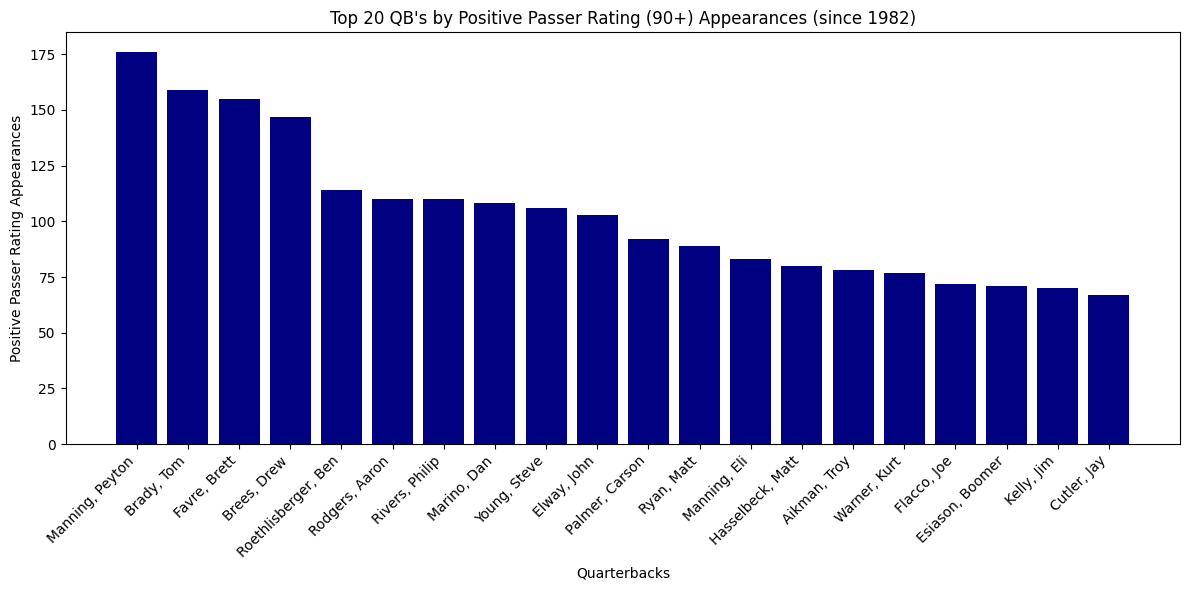

In [28]:

# Get top 20 QBs
top_20_qbs = top_qbs_40plus_games.head(20)

# Plot the bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(top_20_qbs["Name"], top_20_qbs["Positive Passer Rating Appearences"], color='navy')
plt.xlabel("Quarterbacks")
plt.ylabel("Positive Passer Rating Appearances")
plt.title("Top 20 QB's by Positive Passer Rating (90+) Appearances (since 1982)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




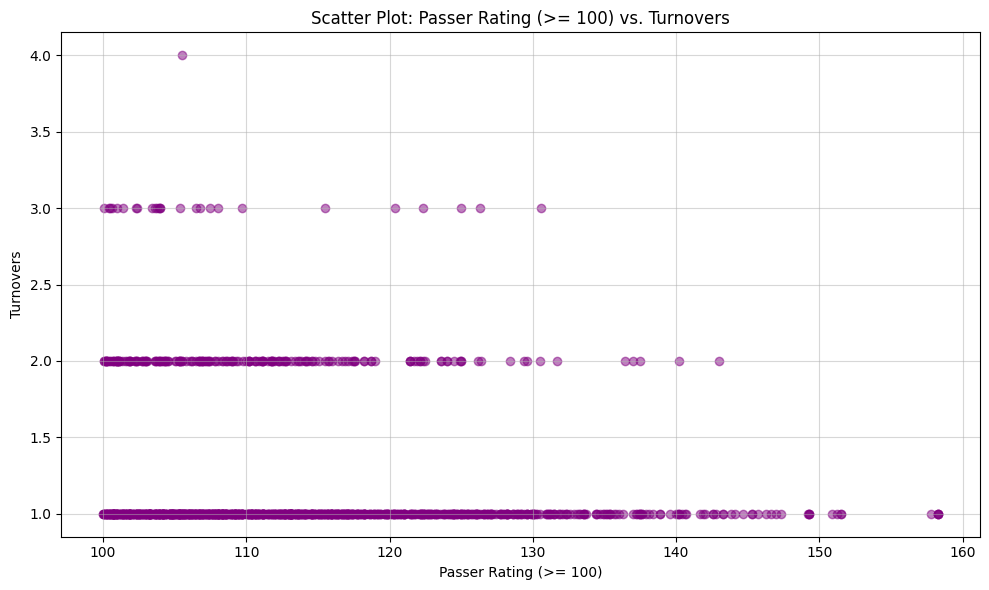

In [29]:
# Filter for games with Passer Rating >= 100
qb_high_rating_100_df = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Passer Rating"].apply(pd.to_numeric, errors="coerce") >= 100].copy()

# Ensure Ints and Fumbles Lost are numeric (coerce errors to NaN then fill NaN with 0) and convert
qb_high_rating_100_df["Ints"] = pd.to_numeric(qb_high_rating_100_df["Ints"], errors="coerce").fillna(0)
qb_high_rating_100_df["Fumbles Lost"] = pd.to_numeric(qb_high_rating_100_df["Fumbles Lost"], errors="coerce").fillna(0)
qb_high_rating_100_df["Turnovers"] = qb_high_rating_100_df["Ints"] + qb_high_rating_100_df["Fumbles Lost"]

# Filter to only games with at least 1 turnover (Int + Fumbles Lost > 0)
qb_high_rating_100_turnover_games = qb_high_rating_100_df[qb_high_rating_100_df["Turnovers"] > 0]

# Display resulting DataFrame
qb_high_rating_100_turnover_games

# Scatter plot between Passer Rating (>=100) and Turnovers (where turnovers > 0)
plt.figure(figsize=(10, 6))
plt.scatter(qb_high_rating_100_turnover_games["Passer Rating"], qb_high_rating_100_turnover_games["Turnovers"], alpha=0.5, color='purple')
plt.xlabel("Passer Rating (>= 100)")
plt.ylabel("Turnovers")
plt.title("Scatter Plot: Passer Rating (>= 100) vs. Turnovers")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


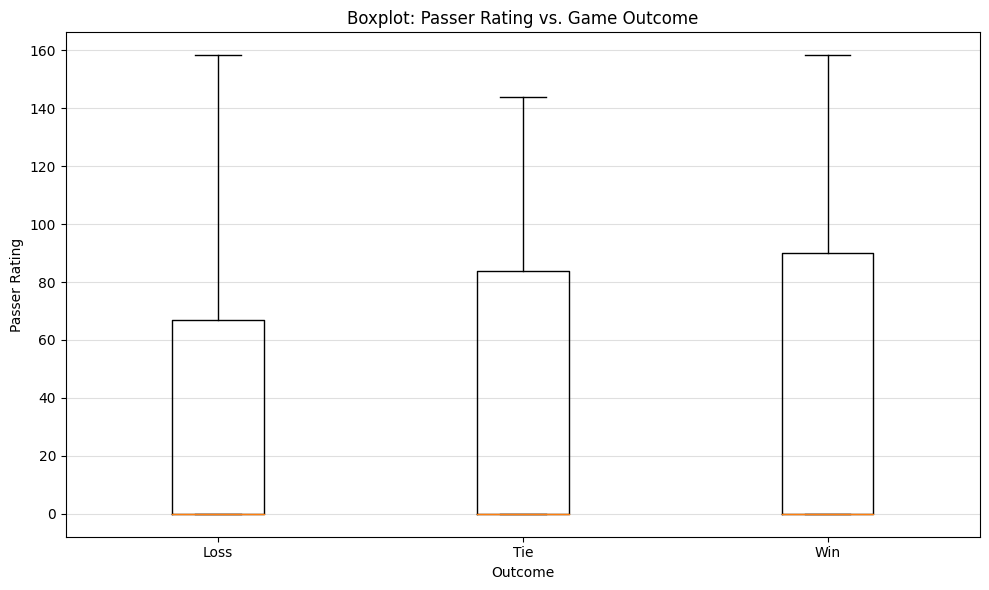

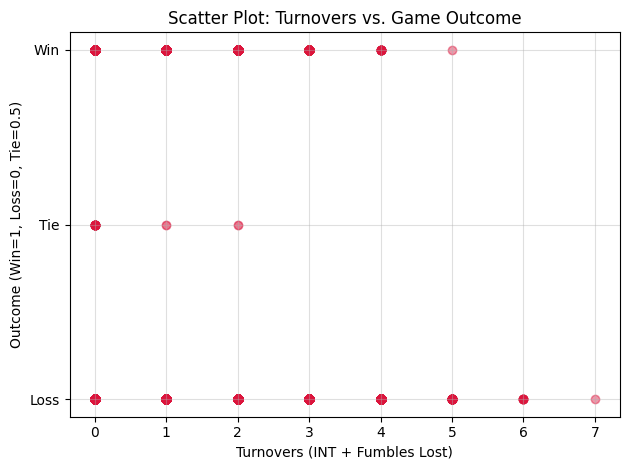

In [30]:

# Correlation between Passer Rating (QBR) and Outcome
# For this, let's map 'Outcome' to numeric (W=1, L=0, T=0.5 or N/A if other)

# Copy dataframe to work with
qb_game_logs_corr = qb_game_logs_df_sorted.copy()

# Parse Passer Rating and Outcome columns
qb_game_logs_corr["Passer Rating"] = pd.to_numeric(qb_game_logs_corr["Passer Rating"], errors="coerce")

# Map Outcome to numeric: 'W' -> 1, 'L' -> 0, 'T' -> 0.5, handle case insensitivity and missing values
def outcome_to_numeric(outcome):
    if isinstance(outcome, str):
        s = outcome.strip().upper()
        if s == "W":
            return 1
        elif s == "L":
            return 0
        elif s == "T":
            return 0.5
    return None

qb_game_logs_corr["Outcome_Numeric"] = qb_game_logs_corr["Outcome"].apply(outcome_to_numeric)

# Drop rows missing either Passer Rating or Outcome_Numeric
qbr_outcome_valid = qb_game_logs_corr.dropna(subset=["Passer Rating", "Outcome_Numeric"])

# Group Passer Rating by Outcome_Numeric for boxplot
data_by_outcome = [
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 0]["Passer Rating"].values,  # Loss
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 0.5]["Passer Rating"].values,  # Tie
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 1]["Passer Rating"].values   # Win
]

plt.figure(figsize=(10,6))
plt.boxplot(data_by_outcome, labels=["Loss", "Tie", "Win"])
plt.xlabel("Outcome")
plt.ylabel("Passer Rating")
plt.title("Boxplot: Passer Rating vs. Game Outcome")
plt.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

# Correlation between Turnovers and Outcome
# Use the already prepared Ints and Fumbles Lost columns (numeric & filled), create Turnovers if not already made.

# Make sure Turnovers column exists and is correct, repeat conversion if not:
qb_game_logs_corr["Ints"] = pd.to_numeric(qb_game_logs_corr["Ints"], errors="coerce").fillna(0)
qb_game_logs_corr["Fumbles Lost"] = pd.to_numeric(qb_game_logs_corr["Fumbles Lost"], errors="coerce").fillna(0)
qb_game_logs_corr["Turnovers"] = qb_game_logs_corr["Ints"] + qb_game_logs_corr["Fumbles Lost"]

# Drop rows missing Turnovers or Outcome_Numeric
turnover_outcome_valid = qb_game_logs_corr.dropna(subset=["Turnovers", "Outcome_Numeric"])

# plt.figure(figsize=(10,6))
plt.scatter(turnover_outcome_valid["Turnovers"], turnover_outcome_valid["Outcome_Numeric"], alpha=0.25, color='crimson')
plt.xlabel("Turnovers (INT + Fumbles Lost)")
plt.ylabel("Outcome (Win=1, Loss=0, Tie=0.5)")
plt.title("Scatter Plot: Turnovers vs. Game Outcome")
plt.yticks([0,0.5,1], ["Loss","Tie","Win"])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()




In [31]:
## 2. Create Outcome Column for Logistic Regression

def outcome_to_numeric(outcome):
    if isinstance(outcome, str):
        s = outcome.strip().upper()
        if s == "W":
            return 1
        elif s == "L" or s == "T": # Treat ties as losses
            return 0
        return None

qb_game_logs_df_sorted["Outcome_Numeric"] = qb_game_logs_df_sorted["Outcome"].apply(outcome_to_numeric)
qb_game_logs_df_sorted.dropna(subset=["Outcome_Numeric"], inplace=True)


3. Attempt 1: Logistic Regression Using Only Passer Rating

/usr/local/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


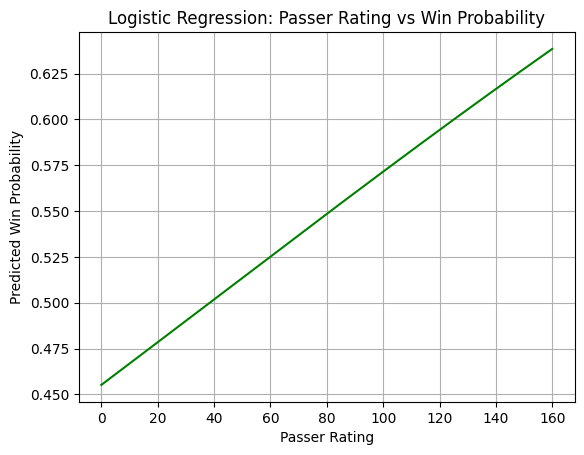

In [32]:
# Ensure Passer Rating is numeric
qb_game_logs_df_sorted["Passer Rating"] = pd.to_numeric(qb_game_logs_df_sorted["Passer Rating"], errors="coerce")

# Prepare X and y
qbr_only = qb_game_logs_df_sorted.dropna(subset=["Passer Rating", "Outcome_Numeric"])
X_qbr = qbr_only[["Passer Rating"]]
y_qbr = qbr_only["Outcome_Numeric"]

# Train model
model_qbr = LogisticRegression()
model_qbr.fit(X_qbr, y_qbr)

# Plot win probability curve
ratings_range = np.linspace(0, 160, 300).reshape(-1, 1)
predicted_curve = model_qbr.predict_proba(ratings_range)[:, 1]


plt.plot(ratings_range, predicted_curve, color='green')
plt.xlabel("Passer Rating")
plt.ylabel("Predicted Win Probability")
plt.title("Logistic Regression: Passer Rating vs Win Probability")
plt.grid(True)
plt.show()

## 🧪 First Logistic Regression Attempt: Passer Rating Only

### 🎯 Goal:
We aimed to test whether a quarterback’s **Passer Rating** alone could predict whether their team would win a game (Win = 1, Loss/Tie = 0). This was done by using **logistic regression**, which is suitable for binary outcomes.

### 🧰 Setup:
- **Feature (X):** `Passer Rating` (real number from 0 to 158.3)
- **Target (y):** `Outcome_Numeric` (1 for Win, 0 for Loss or Tie)
- Logistic Regression model from `sklearn.linear_model`

### 📉 Resulting Output:
After plotting the predicted probabilities using:

```python
ratings_range = np.linspace(0, 160, 300).reshape(-1, 1)
predicted_curve = model.predict_proba(ratings_range)[:, 1]
plt.plot(ratings_range, predicted_curve)


In [33]:
# 4. Add Turnovers as a Feature
# Clean turnover components
qb_game_logs_df_sorted["Ints"] = pd.to_numeric(qb_game_logs_df_sorted["Ints"], errors="coerce").fillna(0)
qb_game_logs_df_sorted["Fumbles Lost"] = pd.to_numeric(qb_game_logs_df_sorted["Fumbles Lost"], errors="coerce").fillna(0)
qb_game_logs_df_sorted["Turnovers"] = qb_game_logs_df_sorted["Ints"] + qb_game_logs_df_sorted["Fumbles Lost"]

# Prepare new df
qb_logit_df = qb_game_logs_df_sorted.dropna(subset=["Passer Rating", "Turnovers", "Outcome_Numeric"])
X = qb_logit_df[["Passer Rating", "Turnovers"]]
y = qb_logit_df["Outcome_Numeric"]
# Train model with both features
model_both = LogisticRegression()
model_both.fit(X, y)

LogisticRegression()

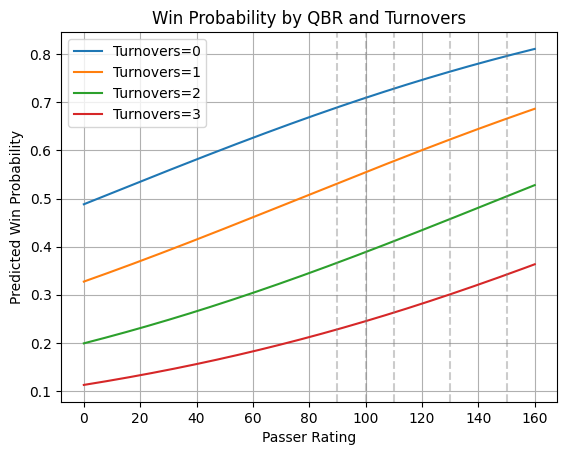

In [34]:
## 5. Plot Predicted Win Probabilities by Passer Rating and Turnovers
for t in [0, 1, 2, 3]:
    test_range = pd.DataFrame({
        "Passer Rating": np.linspace(0, 160, 300),
        "Turnovers": t
    })
    proba = model_both.predict_proba(test_range)[:, 1]
    plt.plot(test_range["Passer Rating"], proba, label=f"Turnovers={t}")
# Add vertical lines for key passer ratings
for rating in [90, 100, 110, 130, 150]:
    plt.axvline(x=rating, color='gray', linestyle='--', alpha=0.4)

plt.xlabel("Passer Rating")
plt.ylabel("Predicted Win Probability")
plt.title("Win Probability by QBR and Turnovers")
plt.legend()
plt.grid(True)
plt.show()

This attempt returns very generic data.  Lets try again

### Attempt 2 at Logistic Regression using both QBR and Turnovers to predict game outcome


In [39]:
X = qb_game_logs_df_sorted[["Passer Rating", "Turnovers"]].copy()
y = (qb_game_logs_df_sorted["Outcome"].str.strip().str.upper() == "W").astype(int)
# Clean data
X = X.dropna()
y = y.loc[X.index]
y


28306    0
1359     1
1960     1
16740    1
10784    1
        ..
24217    1
24224    1
24223    0
24219    0
24215    0
Name: Outcome, Length: 29613, dtype: int64

In [38]:
# Setup and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [49]:
# Predict on real game data (from X)
# Extract predictions from X.  We are solving P(win | Passer Rating, Turnovers)
predicted_probs = model.predict_proba(X)[:, 1]
# Print predicted probabilities 
predicted_probs


array([0.80856842, 0.80856842, 0.80856842, ..., 0.48806973, 0.48806973,
       0.48806973])

/var/folders/cr/sp078qx92kj_1s7d1k0pkm5h0000gn/T/ipykernel_26026/74399946.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = results_df.groupby("QBR_Bin").agg({


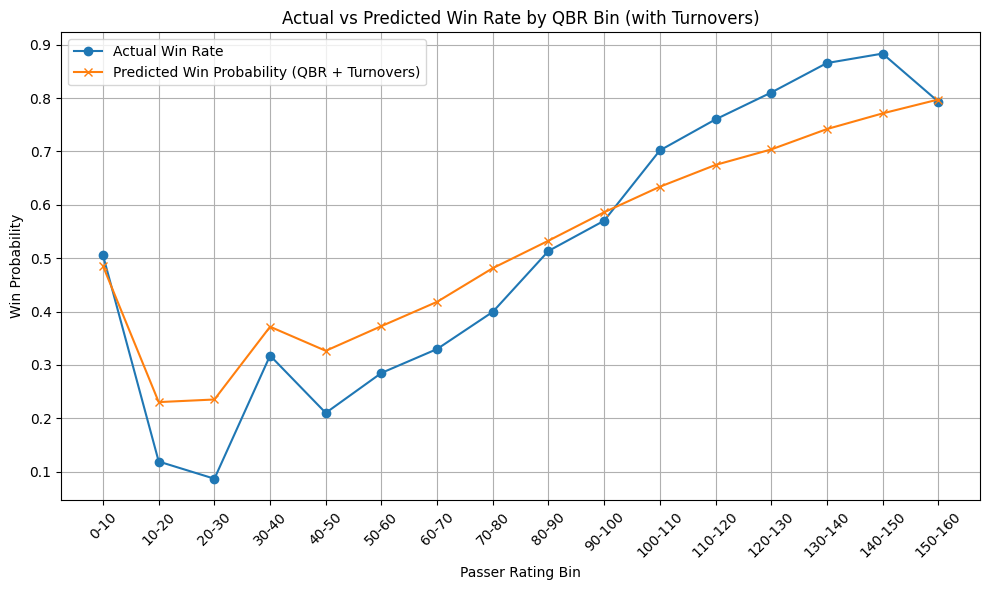

In [ ]:
# Compile Results DataFrame
results_df = X.copy()
results_df["Actual_Win"] = y
results_df["Predicted_Win_Prob"] = predicted_probs
# Create QBR bins
bins = np.arange(0, 170, 10)
labels = [f"{i}-{i+10}" for i in bins[:-1]]
results_df["QBR_Bin"] = pd.cut(results_df["Passer Rating"], bins=bins, labels=labels, include_lowest=True)

summary = results_df.groupby("QBR_Bin").agg({
    "Actual_Win": "mean",
    "Predicted_Win_Prob": "mean"
}).reset_index()

# Plot Actual vs Predicted Win Rate by QBR Bin
plt.figure(figsize=(10, 6))
plt.plot(summary["QBR_Bin"], summary["Actual_Win"], label="Actual Win Rate", marker='o')
plt.plot(summary["QBR_Bin"], summary["Predicted_Win_Prob"], label="Predicted Win Probability (QBR + Turnovers)", marker='x')
plt.xticks(rotation=45)
plt.xlabel("Passer Rating Bin")
plt.ylabel("Win Probability")
plt.title("Actual vs Predicted Win Rate by QBR Bin (with Turnovers)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Interpreting the Win Probability Chart

This chart compares **what actually happened in NFL games** with **what your logistic regression model predicts**.

---

## 🔷 Blue Line — *Actual Win Rate*

This line represents **real outcomes from the data**.

For each **Passer Rating (QBR) bin** (e.g., 70–80, 80–90, etc.):

- We calculate the percentage of games that were actually won.
- Example:  
  - If the 90–100 bin has 100 games and 65 wins → win rate = **0.65**

✅ **This is ground truth** — what really happened on the field.

---

## 🟠 Orange Line — *Predicted Win Probability (QBR + Turnovers)*

This line shows the **average prediction from your logistic regression model** for each QBR bin.

The model uses:
- **Passer Rating**
- **Turnovers**

So each point reflects:
> “Given this QBR range (and associated turnovers), how likely does the model think a win is?”

---

## 🧠 How to Interpret the Two Lines

### Calibration logic:
- **Orange ≈ Blue** → Model is *well-calibrated*
- **Orange below Blue** → Model *underestimates* win probability
- **Orange above Blue** → Model is *overconfident*

### What we see in your chart:
- 🔻 The model **underpredicts wins at very high QBRs (140–160)**
- 📈 The curve is now **properly nonlinear** (not flat anymore)
- 🔁 Adding **Turnovers** helped explain:
  - Low-QBR wins
  - Noisy early bins

✅ Overall: **The model is clearly better than the first attempt**

---

## 📊 What About a p-value?

There is **no single p-value shown on the chart**.

Logistic regression models are evaluated differently. Here are the correct ways to assess it:

---
<br>
✅ The model correctly learns that higher QBR → higher win probability <br>
❌ The model still underpredicts extreme elite QB games<br>



In [50]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X)  # adds intercept term
model_sm = sm.Logit(y, X_with_const)
result = model_sm.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.656137
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                29613
Model:                          Logit   Df Residuals:                    29610
Method:                           MLE   Df Model:                            2
Date:                Mon, 19 Jan 2026   Pseudo R-squ.:                 0.05338
Time:                        20:05:24   Log-Likelihood:                -19430.
converged:                       True   LL-Null:                       -20526.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0477      0.015     -3.101      0.002      -0.078      -0.018
Passer Rating     0.

### Win probability = sigmoid(intercept + 0.0185 × Passer Rating + (-0.0477) × Turnovers)
<br>
For every 1 additional turnover, the odds of winning decrease, because the coefficient is negative.

/var/folders/cr/sp078qx92kj_1s7d1k0pkm5h0000gn/T/ipykernel_26026/2187083133.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = results_df.groupby(['QBR_Bin', 'Turnover_Bin']).agg({


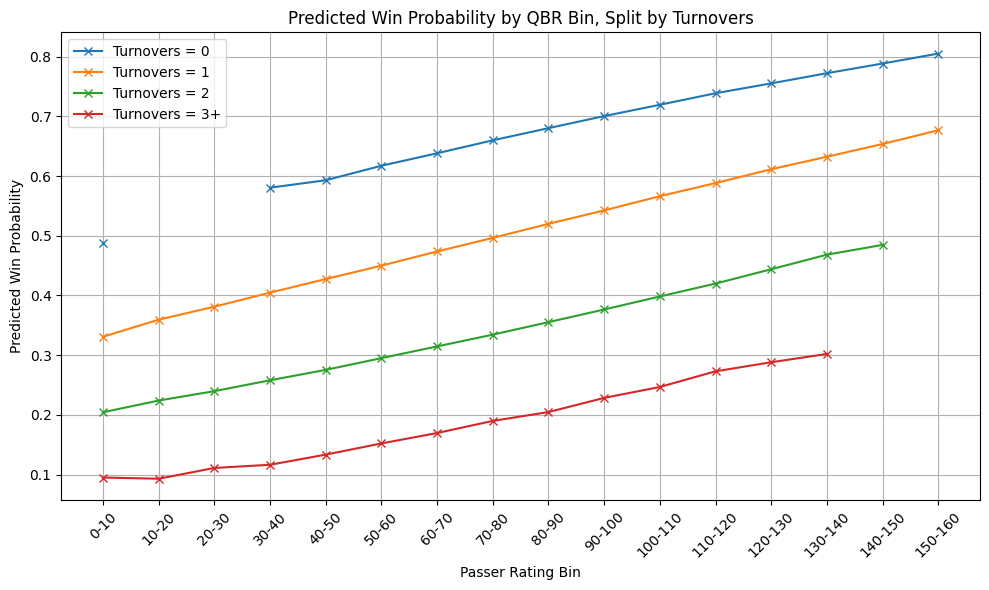

In [51]:
# Bin turnovers into categories (0, 1, 2, 3+)
results_df['Turnover_Bin'] = pd.cut(results_df['Turnovers'], bins=[-1, 0, 1, 2, 10], labels=['0', '1', '2', '3+'])

# Group by QBR bin and Turnover bin
summary = results_df.groupby(['QBR_Bin', 'Turnover_Bin']).agg({
    'Actual_Win': 'mean',
    'Predicted_Win_Prob': 'mean'
}).reset_index()

# Plot each turnover group as a separate line
plt.figure(figsize=(10, 6))
for turnover_group in summary['Turnover_Bin'].unique():
    subset = summary[summary['Turnover_Bin'] == turnover_group]
    plt.plot(subset['QBR_Bin'], subset['Predicted_Win_Prob'], label=f'Turnovers = {turnover_group}', marker='x')

plt.xticks(rotation=45)
plt.xlabel("Passer Rating Bin")
plt.ylabel("Predicted Win Probability")
plt.title("Predicted Win Probability by QBR Bin, Split by Turnovers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This again is not intuitive as the result does not show any data that wasnt obvious before. <br>
❌ Why This Chart Isn’t a Meaningful Result

The chart shows predicted win probability for Passer Rating bins split by Turnover bin (0,1,2,3+), but:

1. Predictions only depend on QBR and Turnovers

The logistic regression model was trained with two input features:

Passer Rating (continuous)

Turnovers (continuous / discrete)

But what you're plotting groups predicted probabilities by bin, not using actual model predictions on real game examples for each bin.

2. It’s summarizing predictions, not model behavior per se

Since model predictions are smooth and logistic, the separation of curves is just reflecting the coefficients:

Higher QBR → higher win chance

More turnovers → lower win chance
...but not revealing anything new or interaction-based.

/usr/local/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


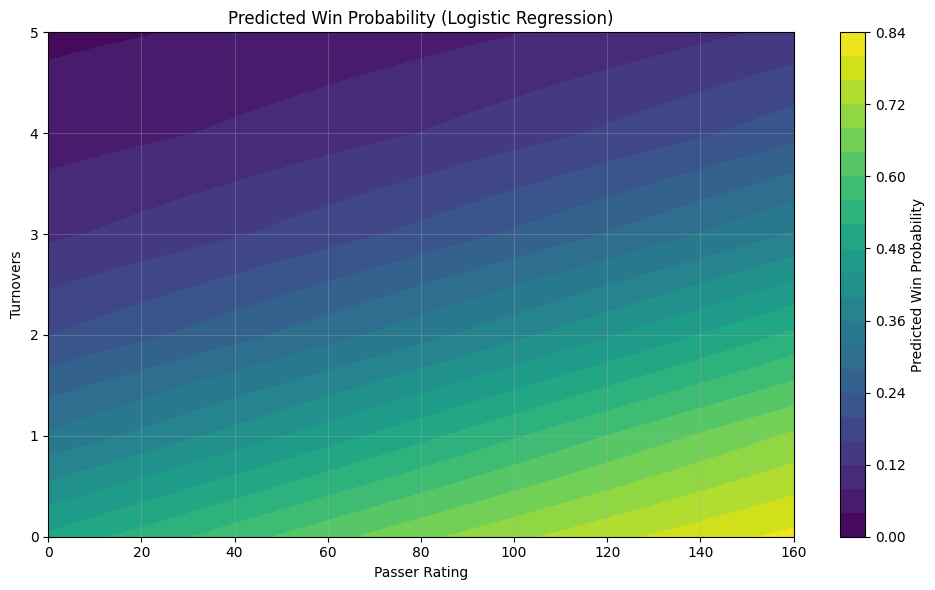

In [52]:
# Define grid over Passer Rating (0-160) and Turnovers (0-5)
qbr_vals = np.linspace(0, 160, 100)
to_vals = np.arange(0, 6)
QBR, TO = np.meshgrid(qbr_vals, to_vals)

# Flatten and predict
X_grid = np.column_stack((QBR.ravel(), TO.ravel()))
pred_probs = model.predict_proba(X_grid)[:, 1].reshape(TO.shape)

# Plot
plt.figure(figsize=(10, 6))
cp = plt.contourf(QBR, TO, pred_probs, levels=20, cmap='viridis')
plt.colorbar(cp, label='Predicted Win Probability')
plt.xlabel('Passer Rating')
plt.ylabel('Turnovers')
plt.title('Predicted Win Probability (Logistic Regression)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # Now includes squares and cross terms
# lets run a logistic regression on this new feature set
model_poly = LogisticRegression(max_iter=1000)
model_poly.fit(X_poly, y)
# Predict on real game data (from X_poly)
predicted_probs_poly = model_poly.predict_proba(X_poly)[:, 1]
# Print predicted probabilities
predicted_probs_poly

array([0.96457473, 0.96457473, 0.96457473, ..., 0.49907854, 0.49907854,
       0.49907854])

# 📊 Logistic Regression Model Summary: Passer Rating & Turnovers

This analysis explains how the logistic regression model predicts NFL game outcomes, how to interpret the win-probability chart, and what the model coefficients mean in clear football terms.

---

## 🔷 Actual vs Predicted Win Probability (Chart Interpretation)

The chart compares **real game outcomes** with **model predictions** across Passer Rating (QBR) bins.

### 🔵 Blue Line — Actual Win Rate

This line represents **what actually happened** in real NFL games.

For each Passer Rating bin (e.g., 70–80, 80–90):
- We compute the percentage of games that were wins.
- Example: if the 90–100 bin contains 100 games and 65 wins, the win rate is **0.65**.

This line is **ground truth**.

---

### 🟠 Orange Line — Predicted Win Probability (QBR + Turnovers)

This line shows the **average predicted probability of winning** from the logistic regression model for each QBR bin.

The model uses:
- Passer Rating  
- Turnovers  

Each point answers:
> “Given this level of QB play and turnovers, how likely is a win according to the model?”

---

### 🧠 How to Interpret the Two Lines

- Orange ≈ Blue → well-calibrated model  
- Orange below Blue → model underestimates win chances  
- Orange above Blue → model is overconfident  

**Observed behavior in this model:**
- The model underpredicts wins at extremely high QBRs (140–160)
- Adding turnovers improved realism and curvature
- Early low-QBR bins improved by explaining noisy wins

---

## 🟧 Coefficient Table (Most Important Section)

This table explains **how each variable affects the probability of winning**.

| Variable | Coef | Interpretation |
|--------|------|----------------|
| **const** | −0.0477 | Intercept. Base log-odds of winning when all features are zero. Not meaningful alone. |
| **Passer Rating** | +0.0094 | Each 1-point increase raises the log-odds of winning by 0.0094. Positive effect. |
| **Turnovers** | −0.6727 | Each turnover sharply decreases win probability. A very costly event. |

---

## 🔎 Converting Log-Odds to Odds Ratios

Log-odds are not intuitive, so we exponentiate the coefficients:

## 📊 Model Quality Metrics

Log-Likelihood Ratio p-value: 0.000
→ The model is statistically significant overall.

Pseudo R²: 0.053
→ ~5.3% of win/loss variation explained by just two variables.
→ This is reasonable in sports data, where many contextual factors affect outcomes.

AUC (if computed):

0.5 = random guessing

0.6–0.7 = useful model

0.7+ = strong predictive power

## 🟩 Key Takeaways

The model correctly learns that higher passer rating increases win probability.

Turnovers dominate: each one roughly halves your chance of winning.

Adding turnovers fixed the flat prediction issue and improved calibration.

The model still underpredicts wins at extreme elite QB performances.

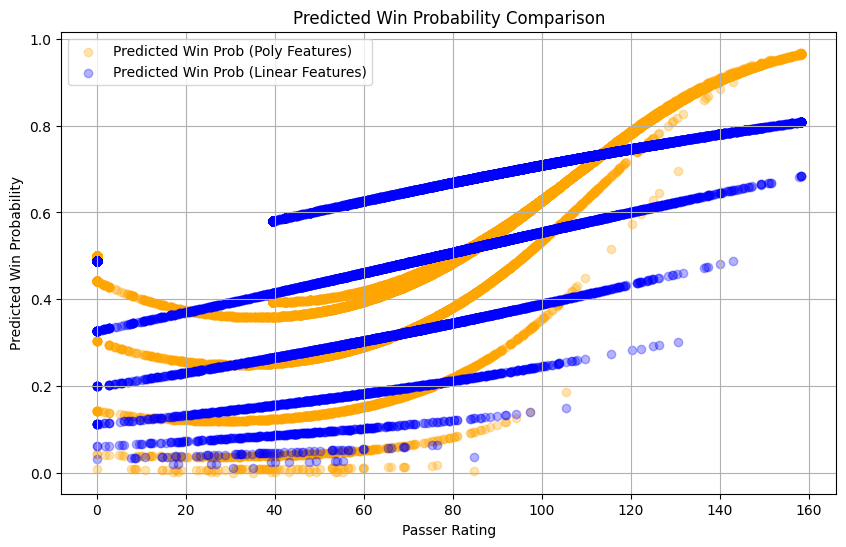

In [54]:
# lets plot predicted_probs_poly
# lets plot predicted_probs
plt.figure(figsize=(10, 6))
plt.scatter(X["Passer Rating"], predicted_probs_poly, alpha=0.3, color='orange', label='Predicted Win Prob (Poly Features)')
plt.scatter(X["Passer Rating"], predicted_probs, alpha=0.3, color='blue', label='Predicted Win Prob (Linear Features)')
plt.xlabel("Passer Rating")
plt.ylabel("Predicted Win Probability")
plt.title("Predicted Win Probability Comparison")
plt.legend()
plt.grid(True)
plt.show()

## What We Are Seeing in the Plot

### 🔵 Linear Model (Blue Points)
- Win probability increases **steadily and evenly**
- Parallel diagonal bands appear
- Probability tops out lower (~0.8)
- Fails to reflect dominance at elite QBRs

### 🟠 Polynomial Model (Orange Points)
- Clear **S-shaped curvature**
- Faster probability growth at high passer ratings
- Lower probabilities at weak QBRs
- Better separation between mediocre and elite performances
- Predictions approach realistic ceilings (near 0.9+)

This curvature is exactly what we *expect* from real game outcomes.

---

## 4️⃣ Why the “Bands” Exist at All

The horizontal/diagonal bands are not a bug.

They occur because:
- Turnovers are discrete (0, 1, 2, 3…)
- Each turnover count shifts the probability curve downward
- Each band corresponds to a different turnover level

________________________________________________________________________________________________________________________________________

## Add Interaction Term + Refit Model

In [57]:
# Filter to only Win/Loss games
results_binary = results_df[results_df["Outcome_Numeric"].isin([0, 1])].copy()

# Features
X = results_binary[["Passer Rating", "Turnovers"]].copy()
X["QBR_x_TO"] = X["Passer Rating"] * X["Turnovers"]

# Target
y = results_binary["Outcome_Numeric"].astype(int)  # Ensure binary int values

# Fit logistic regression
model_interaction = LogisticRegression()
model_interaction.fit(X, y)

LogisticRegression()

Plot the new prediction surface having defined "QBR_x_TO" = PR * TO

In [59]:
qbr_vals = np.linspace(0, 160, 200)
to_vals = np.linspace(0, 5, 200)
qbr_grid, to_grid = np.meshgrid(qbr_vals, to_vals)

# Flatten and create interaction feature
flat_qbr = qbr_grid.ravel()
flat_to = to_grid.ravel()
flat_interact = flat_qbr * flat_to

# Combine into full feature matrix
X_grid = np.vstack([flat_qbr, flat_to, flat_interact]).T

/usr/local/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


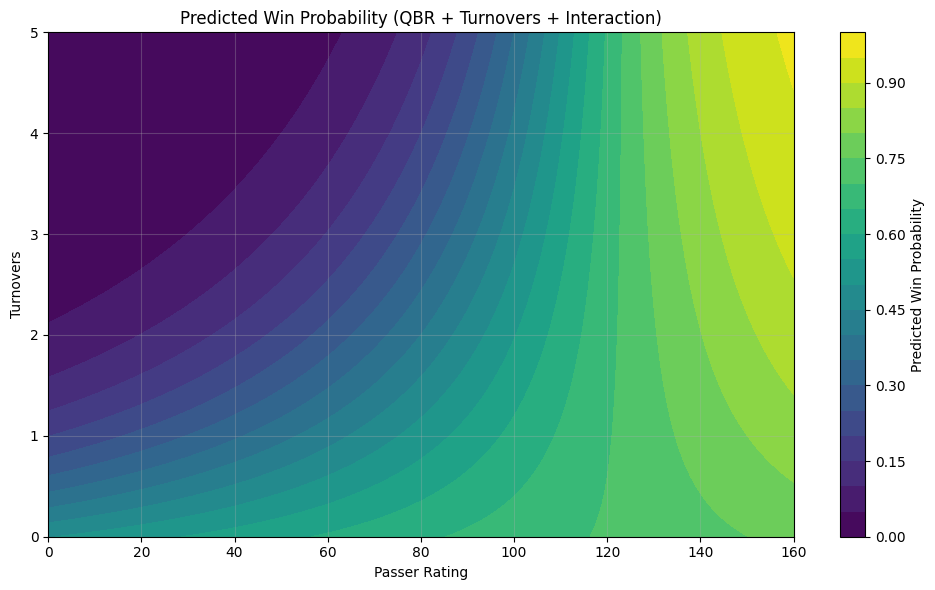

In [60]:
predicted_probs = model_interaction.predict_proba(X_grid)[:, 1]
Z = predicted_probs.reshape(qbr_grid.shape)
plt.figure(figsize=(10, 6))
contour = plt.contourf(qbr_grid, to_grid, Z, cmap="viridis", levels=20)
plt.colorbar(contour, label="Predicted Win Probability")
plt.xlabel("Passer Rating")
plt.ylabel("Turnovers")
plt.title("Predicted Win Probability (QBR + Turnovers + Interaction)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🟢 Logistic Regression: QBR + Turnovers + Interaction

### 🧠 Goal:
To improve our model by including not just `Passer Rating` and `Turnovers`, but also their **interaction** (`QBR * Turnovers`). This allows us to capture the idea that **the impact of turnovers may differ depending on the QB's performance**.

---

### 📈 Plot: Predicted Win Probability Contour Map

This contour plot shows the **predicted win probability** across combinations of:
- **X-axis**: Passer Rating (QBR)
- **Y-axis**: Turnovers
- **Color**: Predicted probability of winning the game (from 0 to 1)

Each point is a prediction made by the logistic regression model, and the color gradient reflects how likely a win is for that (QBR, Turnovers) combination.

---

### 🔍 Interpretation:

- **High QBR & low turnovers = highest win probability**
- **Low QBR & high turnovers = lowest win probability**
- The **curved contours** (instead of straight lines) reflect the **interaction effect**:
  - A turnover hurts more when your QBR is already bad
  - A high QBR can somewhat **mitigate** the effect of a turnover

This shows the model is now **nonlinear** and better matches intuition about real football outcomes.

---

### ✅ Why Use Interaction Terms?

- Without interactions, the model assumes QBR and Turnovers impact wins independently.
- With interaction: we model that **context matters** — a turnover may not be as damaging if you had a great performance otherwise.



# 🏈 NFL QB Logistic Regression Analysis: Passer Rating & Turnovers

## ✅ Summary: What We Did

### 1. Cleaned and Prepared Data
- Loaded QB game logs from Kaggle dataset.
- Removed preseason games and filled missing values (`fillna(0)`).
- Converted key columns (`Passer Rating`, `Ints`, `Fumbles Lost`) to numeric.
- Created a new feature:  
  **`Turnovers = Ints + Fumbles Lost`**

---

### 2. Built the Logistic Regression Model
- **Target (`y`)**: Game Outcome  
  - `1` = Win  
  - `0` = Loss (Ties treated as losses or excluded)

- **Features (`X`)**:  
  - `Passer Rating` (0–158)  
  - `Turnovers` (0–5+)

- Used `LogisticRegression` from **sklearn** and validated with **statsmodels.Logit**.

---

### 3. Statistical Output (via StatsModels)
| Feature         | Coefficient | Interpretation                        |
|----------------|-------------|----------------------------------------|
| Passer Rating   | +0.0094     | Each additional point increases win odds |
| Turnovers       | -0.6727     | Each turnover drastically decreases odds |

- **p-values** for both: `< 0.001` (very significant)
- **Pseudo R² ≈ 0.053** → Low but expected for simple model

---

### 4. Visualizations Created

#### 📈 A. Win Curves
- Line plots showed win rate rises with Passer Rating.
- Turnovers shift the curve downward.

#### 📉 B. Odds Ratios (Bar Plot)
- Passer Rating: ~1.009  
- Turnovers: ~0.51  
  → One turnover reduces odds of winning by nearly **50%**

#### 🎨 C. Heatmap
- Color gradient shows win probability across:
  - X-axis: Passer Rating
  - Y-axis: Turnovers
- Clear trend:  
  High QBR + low turnovers = **high win chance**  
  Low QBR + many turnovers = **very low win chance**

#### 📊 D. Fixed-QBR Line Graph
- Plotted predicted win probabilities for specific ratings (90, 100, 110, 130, 150).
- Showed how turnovers impact win probability **at different rating levels**.

---

## ✅ Key Takeaways

1. **Passer Rating correlates strongly with wins**  
   Even small rating increases boost win chance.

2. **Turnovers are extremely costly**  
   Each one can slash win odds—especially with lower QBRs.

3. **Interaction between QBR and Turnovers matters**  
   High QBR can offset a turnover, but not multiple.

4. **Logistic regression** is effective for binary outcomes like win/loss.


